# Portfolio Risk-Return Analyzer

This notebook presents a small portfolio analysis project based on real financial market data.

The objective is to study how a portfolio of risky assets behaves in terms of **return**, **volatility**, and **risk-adjusted performance**, and to compare it with a market benchmark.

## Project goals

In this notebook, we will:

- download historical stock price data
- compute daily returns
- estimate annualized return and volatility
- study correlations between assets
- construct a weighted portfolio
- calculate portfolio return, risk, and Sharpe ratio
- compare the portfolio with the S&P 500
- visualize cumulative performance and drawdowns

## Assets considered

The portfolio is made of the following stocks:

- TSLA
- NVDA
- META

The benchmark is the **S&P 500 index** (`^GSPC`).

This notebook is meant to be both a coding exercise and a first introduction to portfolio analysis in Python.

In [1]:

# Install yfinance if needed
# Uncomment the next line in a fresh environment
# !pip install yfinance --quiet


In [2]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully.")


Libraries loaded successfully.



## 1. Defining the inverstment universe

Choose assets, dates, and portfolio weights

Weights represent the propotion of wealth invested in each asset. They must sum to 1.


In [19]:

# Risky assets in the portfolio
portfolio_tickers = ["TSLA", "NVDA", "META"]

# Benchmark
benchmark_ticker = "^GSPC"

# Full list for download
tickers = portfolio_tickers + [benchmark_ticker]

# Date range
start_date = "2018-01-01"
end_date = "2025-12-31"

# Portfolio weights
weights = np.array([0.30, 0.40, 0.30])

# Quick checks
assert len(weights) == len(portfolio_tickers), "Number of weights must match number of portfolio assets."
assert np.isclose(weights.sum(), 1), "Portfolio weights must sum to 1."

print("Portfolio tickers:", portfolio_tickers)
print("Benchmark:", benchmark_ticker)
print("Weights:", weights)
print("Sum of weights:", weights.sum())


Portfolio tickers: ['TSLA', 'NVDA', 'META']
Benchmark: ^GSPC
Weights: [0.3 0.4 0.3]
Sum of weights: 1.0



# 2. Download historical price data

We now retrieve historical closing prices for all selected assets.


In [ ]:

prices = yf.download(tickers, start=start_date, end=end_date)["Close"].dropna() #dropna drops unavailable data

print(f"Number of trading days: {len(prices)}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.head()


C:\Users\ebens\AppData\Local\Temp\ipykernel_23476\3060033023.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)["Close"].dropna()
[*********************100%***********************]  4 of 4 completed

Number of trading days: 2010
Date range: 2018-01-02 to 2025-12-30


Ticker,META,NVDA,TSLA,^GSPC
Date,,,,
2018-01-02,180.007385,4.928266,21.368668,2695.810059
2018-01-03,183.232101,5.252614,21.150000,2713.060059
2018-01-04,182.894730,5.280303,20.974667,2723.989990
2018-01-05,185.395126,5.325049,21.105333,2743.149902
2018-01-08,186.813965,5.488213,22.427334,2747.709961


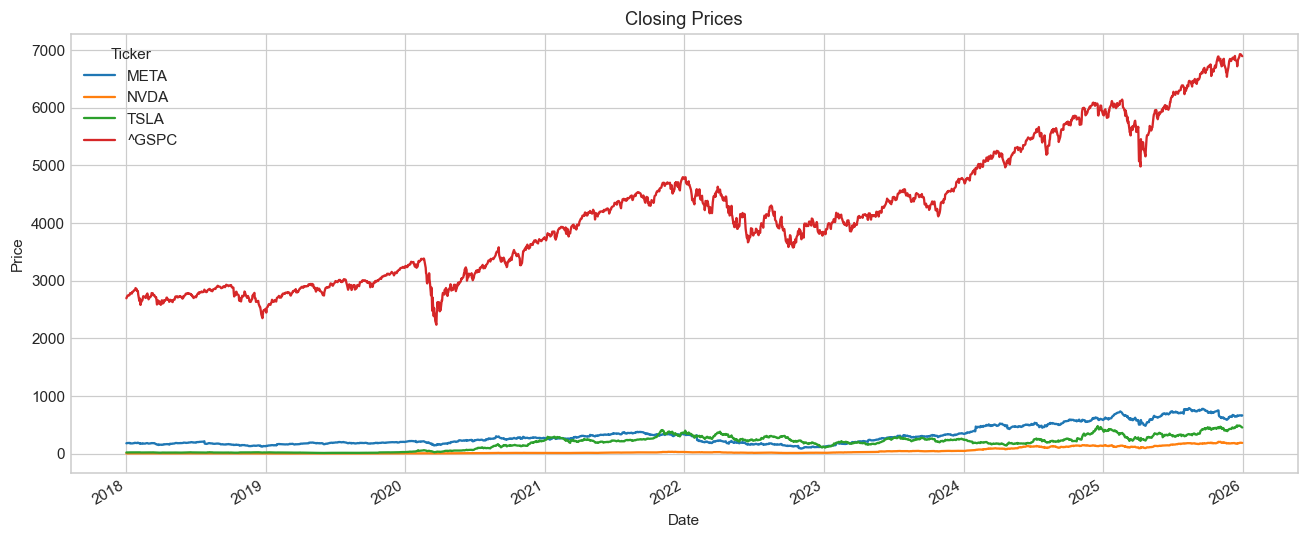

In [21]:

prices.plot(title="Closing Prices", ylabel="Price")
plt.tight_layout()
plt.show()


## 3. Compute daily returns

Asset prices themselves are not directly comparable because they depend on the scale of each stock.

For that reason, we convert prices into **daily simple returns**, defined by

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$


This tells us the percentage gain or loss from one trading day to the next.

In [6]:

returns = prices.pct_change().dropna()
returns.head()


Ticker,META,NVDA,TSLA,^GSPC
Date,,,,
2018-01-03,0.017914,0.065814,-0.010233,0.006399
2018-01-04,-0.001841,0.005271,-0.008290,0.004029
2018-01-05,0.013671,0.008474,0.006230,0.007034
2018-01-08,0.007653,0.030641,0.062638,0.001662
2018-01-09,-0.002178,-0.000270,-0.008085,0.001303


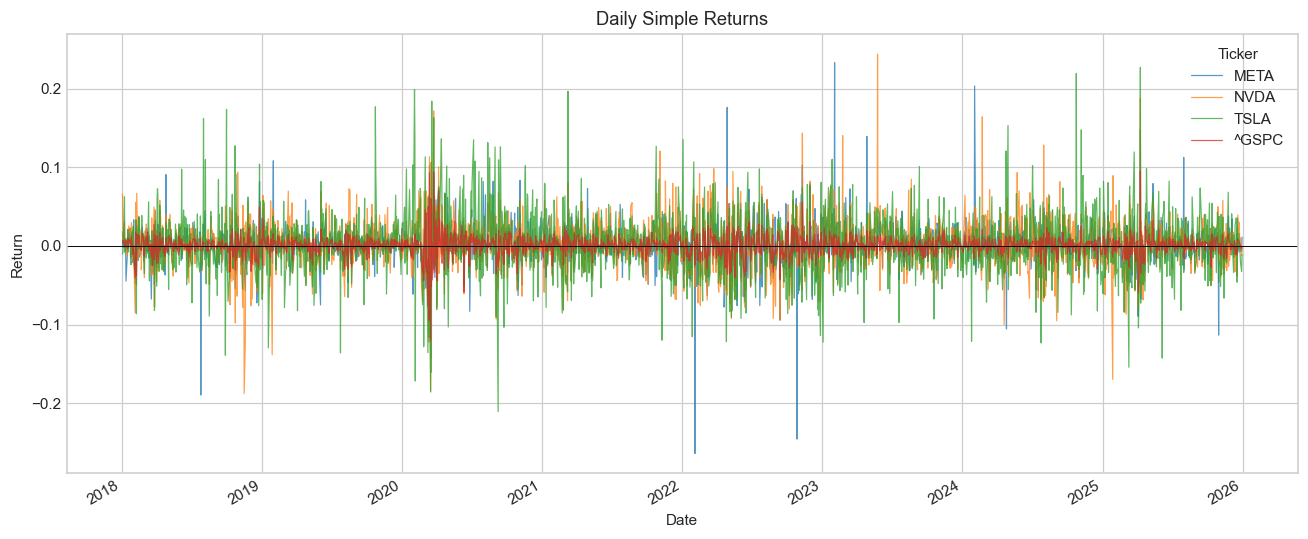

In [7]:

returns.plot(title="Daily Simple Returns", ylabel="Return", alpha=0.75, linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()


## 4. Measure return and risk for each asset

To summarize each asset individually, we compute:

- the **mean return**, which measures average performance
- the **standard deviation of returns**, which measures volatility and is commonly used as a proxy for risk

Because the data is daily, we annualize these quantities using the standard convention of **252 trading days per year**:

- annualized mean return = daily mean × 252
- annualized volatility = daily standard deviation × sqrt(252)

This gives us quantities that are easier to interpret and compare.

In [8]:

daily_mean = returns.mean()
daily_std = returns.std()

annual_mean = daily_mean * 252
annual_std = daily_std * np.sqrt(252)

summary = pd.DataFrame({
    "Annual Return (%)": (annual_mean * 100).round(2),
    "Annual Volatility (%)": (annual_std * 100).round(2)
})

summary


,Annual Return (%),Annual Volatility (%)
Ticker,,
META,25.10,41.46
NVDA,58.82,51.30
TSLA,58.54,63.68
^GSPC,13.71,19.60


### Interpreting return and volatility together

Annual return and annual volatility should be read jointly rather than separately.

A higher annual return is attractive because it means the asset delivered better average performance over the period.  
However, this return often comes with higher volatility, meaning that returns fluctuate more strongly through time and the investment is less stable.

This is the central trade-off in portfolio analysis:
- **return** measures reward
- **volatility** measures risk

The goal is to find a good balance between the two.

This is why comparing assets in a **risk-return space** is useful: it shows whether higher returns are achieved at the cost of substantially higher risk.  

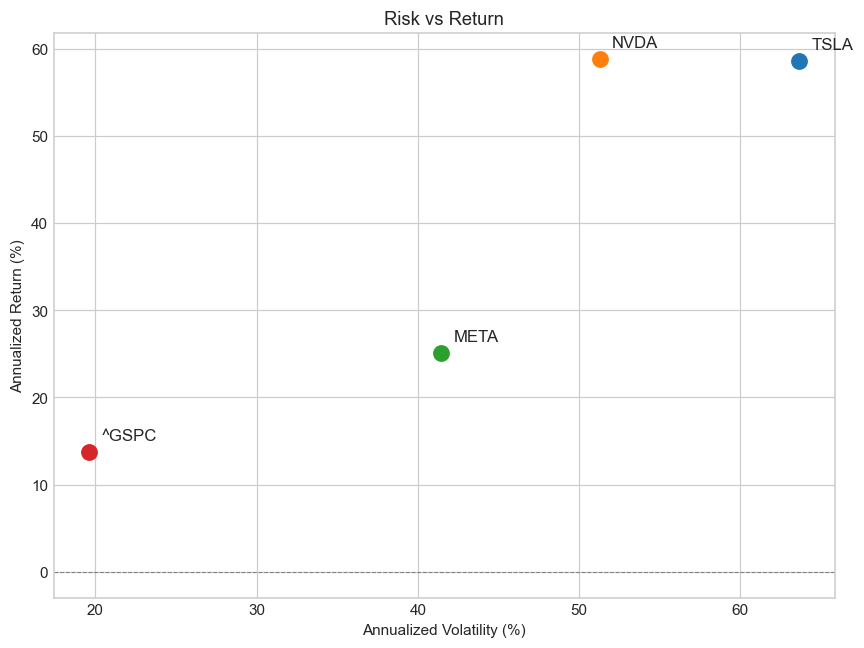

In [9]:

fig, ax = plt.subplots(figsize=(8, 6))

for ticker in tickers:
    ax.scatter(annual_std[ticker] * 100, annual_mean[ticker] * 100, s=100)
    ax.annotate(
        ticker,
        (annual_std[ticker] * 100, annual_mean[ticker] * 100),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )

ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Risk vs Return")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()


## 5. Study dependence between assets
Two important tools are:

- the **correlation matrix**, which shows the strength of co-movements between returns
- the **covariance matrix**, which is required to compute portfolio risk

In [ ]:

corr_matrix = returns[portfolio_tickers].corr()
cov_matrix_daily = returns[portfolio_tickers].cov()
cov_matrix_annual = cov_matrix_daily * 252

print("Correlation matrix:")
display(corr_matrix.round(3)) # standardized values, 3 decimals is enough

print("Annualized covariance matrix:")
display(cov_matrix_annual.round(4)) # scale-dependent values, keep slightly more precision


Correlation matrix:


Ticker,TSLA,NVDA,META
Ticker,,,
TSLA,1.000,0.444,0.339
NVDA,0.444,1.000,0.525
META,0.339,0.525,1.000


Annualized covariance matrix:


Ticker,TSLA,NVDA,META
Ticker,,,
TSLA,0.4056,0.1451,0.0894
NVDA,0.1451,0.2632,0.1117
META,0.0894,0.1117,0.1719


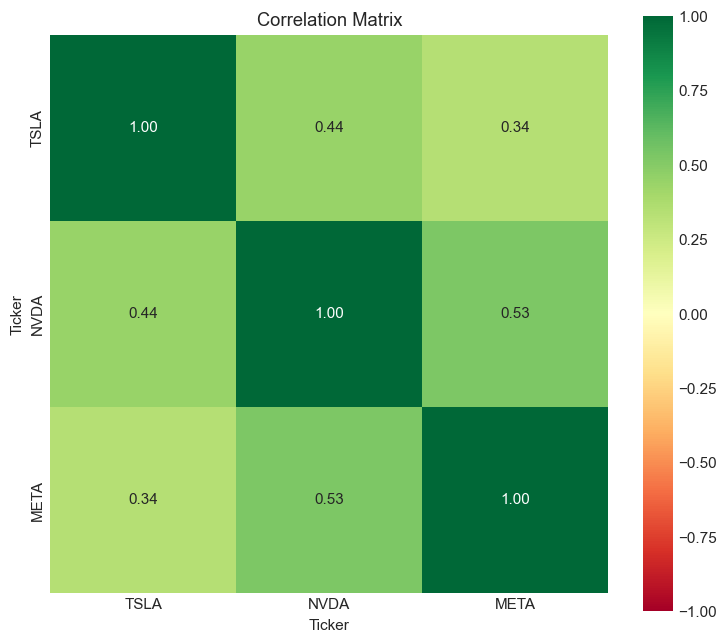

In [11]:

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



## 6. Portfolio expected return and volatility

For portfolio weights $w$:

- expected return: $E[R_p] = w^T \mu$
- variance: $\sigma_p^2 = w^T \Sigma w$
- volatility: $\sigma_p = \sqrt{w^T \Sigma w}$


In [12]:

portfolio_annual_return = np.dot(weights, annual_mean[portfolio_tickers])
portfolio_annual_volatility = np.sqrt(weights.T @ cov_matrix_annual.values @ weights)

portfolio_stats = pd.DataFrame({
    "Metric": ["Portfolio Annual Return", "Portfolio Annual Volatility"],
    "Value": [portfolio_annual_return, portfolio_annual_volatility]
})

portfolio_stats["Value (%)"] = (portfolio_stats["Value"] * 100).round(2)
portfolio_stats[["Metric", "Value (%)"]]


,Metric,Value (%)
0,Portfolio Annual Return,48.62
1,Portfolio Annual Volatility,41.45


## 7. Build the portfolio return series

We now build the **daily return series** of the portfolio itself by taking the weighted average of the individual asset returns.  
This allows us to study how the portfolio evolves through time and to compare it directly with the benchmark.

In [13]:

portfolio_returns = returns[portfolio_tickers] @ weights
portfolio_returns.name = "Portfolio"

portfolio_returns.head()


Date
2018-01-03    0.028630
2018-01-04   -0.000931
2018-01-05    0.009360
2018-01-08    0.033344
2018-01-09   -0.003187
Name: Portfolio, dtype: float64

## 8. Evaluate risk-adjusted performance with the Sharpe ratio

A high return is not enough to judge whether a portfolio is attractive.  
We also need to ask whether that return is sufficiently high relative to the risk taken.

For this purpose, we use the **Sharpe ratio**, defined as

$$
S = \frac{E[R_p] - r_f}{\sigma_p}
$$

where:

- $E[R_p]$ is the expected portfolio return
- $r_f$ is the risk-free rate
- $\sigma_p$ is the portfolio volatility

The Sharpe ratio measures the **excess return per unit of risk**.  
A higher Sharpe ratio indicates better risk-adjusted performance.

In [14]:

risk_free_rate = 0.02

portfolio_sharpe = (portfolio_annual_return - risk_free_rate) / portfolio_annual_volatility

benchmark_annual_return = annual_mean[benchmark_ticker]
benchmark_annual_volatility = annual_std[benchmark_ticker]
benchmark_sharpe = (benchmark_annual_return - risk_free_rate) / benchmark_annual_volatility

sharpe_table = pd.DataFrame({
    "Asset": ["Portfolio", benchmark_ticker],
    "Annual Return (%)": [portfolio_annual_return * 100, benchmark_annual_return * 100],
    "Annual Volatility (%)": [portfolio_annual_volatility * 100, benchmark_annual_volatility * 100],
    "Sharpe Ratio": [portfolio_sharpe, benchmark_sharpe]
}).round(3)

sharpe_table


,Asset,Annual Return (%),Annual Volatility (%),Sharpe Ratio
0,Portfolio,48.620,41.452,1.125
1,^GSPC,13.712,19.603,0.597


## 9. Compare cumulative performance

To make the comparison more intuitive, we compute the growth of 1 dollar invested at the beginning of the sample period.

In [15]:

comparison_returns = pd.concat(
    [portfolio_returns, returns[benchmark_ticker]],
    axis=1
)
comparison_returns.columns = ["Portfolio", benchmark_ticker]

cumulative_growth = (1 + comparison_returns).cumprod()
cumulative_growth.head()


,Portfolio,^GSPC
Date,,
2018-01-03,1.028630,1.006399
2018-01-04,1.027672,1.010453
2018-01-05,1.037291,1.017561
2018-01-08,1.071879,1.019252
2018-01-09,1.068462,1.020580


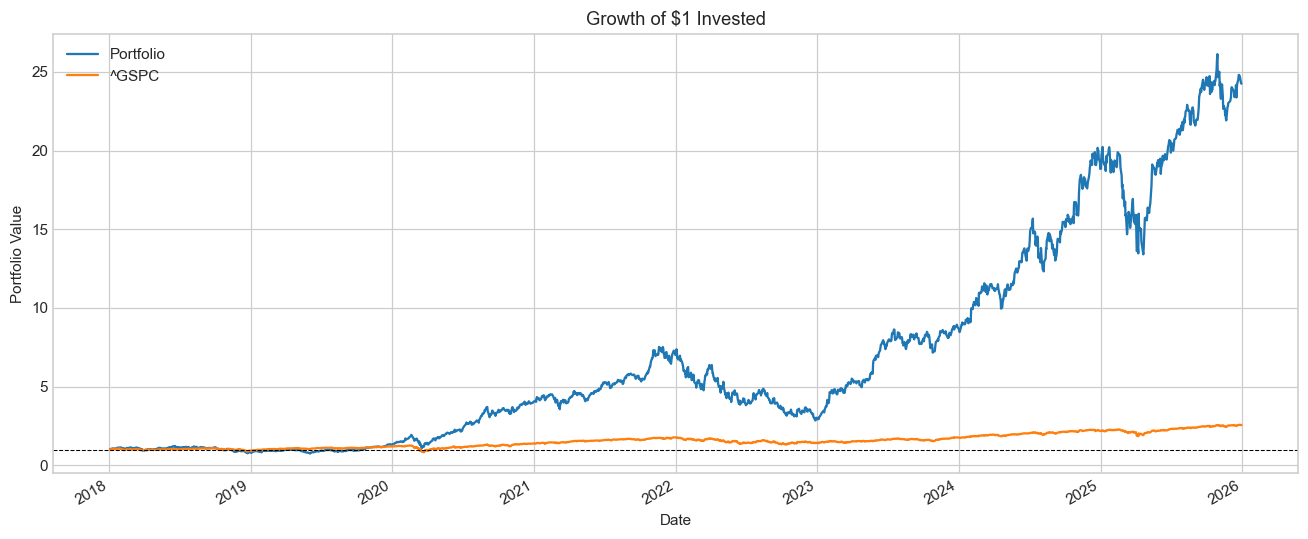

In [16]:

cumulative_growth.plot(title="Growth of $1 Invested", ylabel="Portfolio Value", linewidth=1.5)
plt.axhline(1, color="black", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()



## 10. Drawdown analysis

Drawdown measures the percentage drop from the previous peak.
It is a useful indicator of downside risk and helps us understand how painful the worst phases of the investment path were.


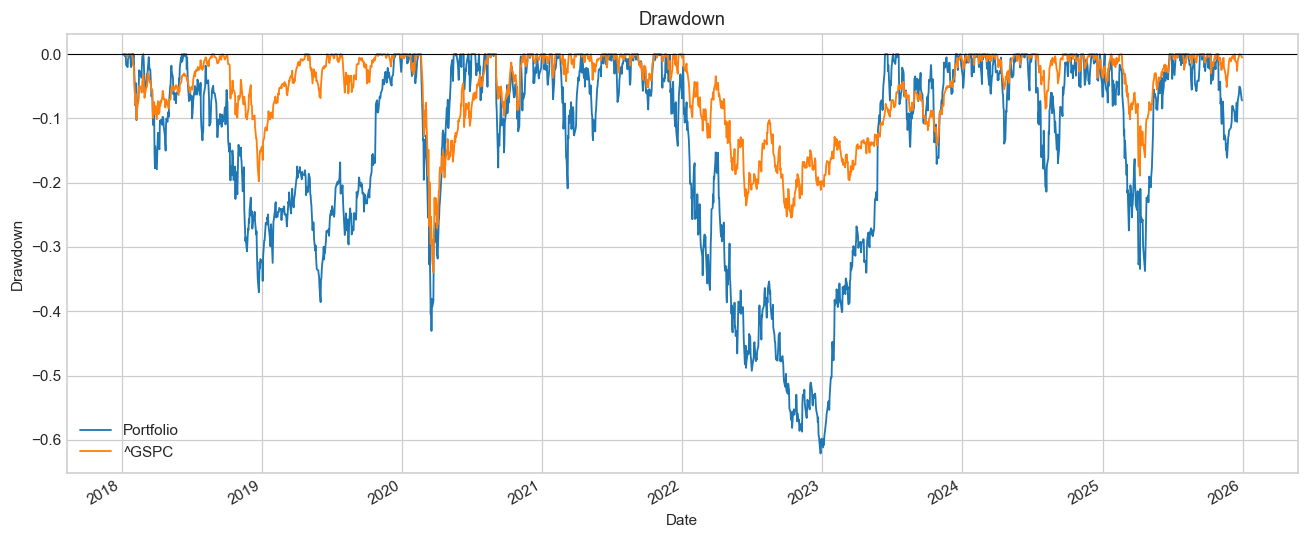

In [17]:

running_max = cumulative_growth.cummax()
drawdown = cumulative_growth / running_max - 1

drawdown.plot(title="Drawdown", ylabel="Drawdown", linewidth=1.2)
plt.axhline(0, color="black", linewidth=0.7)
plt.tight_layout()
plt.show()


In [18]:

max_drawdown = drawdown.min().sort_values()

max_drawdown.to_frame(name="Maximum Drawdown").style.format("{:.2%}")


,Maximum Drawdown
Portfolio,-62.12%
^GSPC,-33.92%


## 11. Interpretation and discussion

The results highlight several key insights:

1. Diversification effects: Combining multiple assets allowed a reduction in overall portfolio volatility compared to individual components, illustrating the fundamental benefit of diversification.
2. Risk-return trade-off: While the portfolio may not always outperform the benchmark in raw returns, it often achieves a more efficient balance between return and risk.
3. Risk-adjusted performance: The Sharpe ratio provides a more meaningful comparison than returns alone, showing whether the portfolio adequately compensates for the level of risk taken.
4. Downside risk: Drawdown analysis reveals that even well-diversified portfolios remain exposed to significant losses during market stress, emphasizing the importance of tail risk management.

Overall, this study demonstrates that portfolio evaluation must go beyond performance metrics and incorporate volatility, correlation structure, and downside risk.